# Logistic Regression for Binary Classification

This notebook builds a Logistic Regression model to predict (binary outcomes) 
customer churn using the Churn Prediction dataset.

Tools: Python | Pandas | Scikit-learn | Matplotlib

In [60]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

## Step 1: Load and Preprocess the Dataset
Loading the Churn dataset and encoding categorical columns 
using Label Encoding. All object and boolean columns are 
automatically detected and encoded using a loop.

In [8]:
df = pd.read_csv('../../Data Set For Task/Churn Prdiction Data/churn-bigml-80.csv');

In [9]:
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [25]:
columns = df.select_dtypes(include=['object', 'bool']).columns.tolist()
print(columns)

['State', 'International plan', 'Voice mail plan', 'Churn']


In [26]:
le = LabelEncoder()

for col in columns:
    df[col] = le.fit_transform(df[col])

df.head()


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,16,128,415,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,35,107,415,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,31,137,415,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,35,84,408,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,36,75,415,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


## Step 2: Train Test Split
Splitting the dataset into 80% training and 20% testing sets.
Target column: Churn (0 = No Churn, 1 = Churn)

In [30]:
x = df.drop(columns=["Churn"])
y = df["Churn"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(df.shape)
print(x_train.shape)
print(x_test.shape)

(2666, 20)
(2132, 19)
(534, 19)


## Step 3: Train Logistic Regression Model (Without Scaling)
Training without scaling to demonstrate convergence issues.

In [33]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## Step 4: Scale Features
Scaling features using StandardScaler to fix convergence issues.
fit_transform on training, transform on test to avoid data leakage.

In [35]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [40]:
model = LogisticRegression(max_iter=100)
model.fit(x_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [41]:
print(model.n_iter_)

[13]


Without scaling → ConvergenceWarning, 1000+ iterations ❌

With scaling    → converged in 13 iterations ✅

## Step 5: Model Predictions
Testing the trained model on unseen test data and comparing 
predicted vs actual churn values.

In [45]:
y_pred = model.predict(x_test_scaled)

results = pd.DataFrame({
    "Prediction Values" : y_pred,
    "Actual Values": y_test.values
})

results.head()

,Prediction Values,Actual Values
0,1,1
1,0,0
2,0,0
3,0,1
4,0,1


## Step 6: Interpret Coefficients and Odds Ratio

Coefficients represent how much each feature affects the 
raw score before the sigmoid function — hard to interpret directly.

Odds Ratio (e^coefficient) converts this to a more meaningful scale:
- Odds Ratio > 1 → feature increases probability of churn
- Odds Ratio < 1 → feature decreases probability of churn
- Odds Ratio = 1 → feature has no effect on churn

For example, Odds Ratio of 1.9 means a 1 unit increase 
in that feature makes churn 1.9x more likely.

In [76]:
coefficients = model.coef_[0]
feature_names = x_train.columns.tolist()
odds_ratio = np.exp(coefficients)

coef_df = pd.DataFrame({
    'Feature' : feature_names,
    'Coefficient' : coefficients,
    'Odds Ratio' : odds_ratio
})

coef_df = coef_df.sort_values('Odds Ratio', ascending=False)
print(coef_df)

                   Feature  Coefficient  Odds Ratio
3       International plan     0.667418    1.949199
18  Customer service calls     0.622184    1.862992
6        Total day minutes     0.371052    1.449259
8         Total day charge     0.370157    1.447962
5    Number vmail messages     0.328090    1.388315
17       Total intl charge     0.150671    1.162614
9        Total eve minutes     0.144267    1.155193
11        Total eve charge     0.142849    1.153555
15      Total intl minutes     0.139844    1.150095
12     Total night minutes     0.076498    1.079500
14      Total night charge     0.074716    1.077578
7          Total day calls     0.074447    1.077289
1           Account length     0.041977    1.042870
10         Total eve calls     0.014832    1.014943
0                    State     0.000479    1.000479
13       Total night calls    -0.035473    0.965149
2                Area code    -0.053273    0.948121
16        Total intl calls    -0.281862    0.754377
4          V

## Step 7: Evaluate Model Performance
Evaluating the model using:
- Accuracy  → overall correct predictions
- Precision → out of predicted churners, how many actually churned
- Recall    → out of actual churners, how many did we catch
- F1 Score  → balance between precision and recall
- AUC       → numerical score of ROC curve (0.5 = random, 1.0 = perfect)

In [98]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision: .4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 score: {f1: .4f}")
print(f"AUC: {auc:.4f}")

Accuracy : 0.8596
Precision:  0.5625
Recall: 0.2278
F1 score:  0.3243
AUC: 0.5985


In [59]:
df['Churn'].value_counts()

Churn
0    2278
1     388
Name: count, dtype: int64

Problem: Class Imbalance

## Step 8: Handling Class Imbalance

Initial evaluation revealed a class imbalance issue:
- Non-churners (0): 2278 
- Churners (1):     388  

This caused the model to be biased towards the majority class,
resulting in high accuracy but very low Recall (23%) —
which is problematic for churn prediction since missing 
actual churners is costly.

Solution: Retrain with class_weight='balanced' which 
automatically assigns higher penalty to the minority class (churners),
forcing the model to pay more attention to them.

In [91]:
balanced_model = LogisticRegression(max_iter=1000, class_weight="balanced")
balanced_model.fit(x_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [94]:
balanced_pred = balanced_model.predict(x_test_scaled)
balanced_result = pd.DataFrame({
    'Predicted Values': balanced_pred,
    'Actual Values' : y_test.values
})

print(balanced_result.head())

   Predicted Values  Actual Values
0                 1              1
1                 1              0
2                 0              0
3                 1              1
4                 1              1


In [100]:
accuracy = accuracy_score(y_test, balanced_pred)
precision = precision_score(y_test, balanced_pred)
recall = recall_score(y_test, balanced_pred)
f1 = f1_score(y_test, balanced_pred)
auc = roc_auc_score(y_test, balanced_pred)

print(f'Accuracy:  {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1 Score:  {f1:.4f}')
print(f'AUC:       {auc:.4f}')

Accuracy:  0.7603
Precision: 0.3478
Recall:    0.7089
F1 Score:  0.4667
AUC:       0.7390


Results after retraining:
- Recall improved from 23% to 71% ✅
- AUC improved from 0.59 to 0.77 ✅
- Tradeoff: Precision decreased from 56% to 35%
- Overall a better model for churn prediction!

## Step 9: ROC Curve
Visualizing the tradeoff between True Positive Rate (Recall) 
and False Positive Rate at every threshold.
The further the curve from the red diagonal, the better the model.
AUC = 0.77 → model is 77% good at distinguishing churners from non-churners.

In [101]:
y_prob = model.predict_proba(x_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

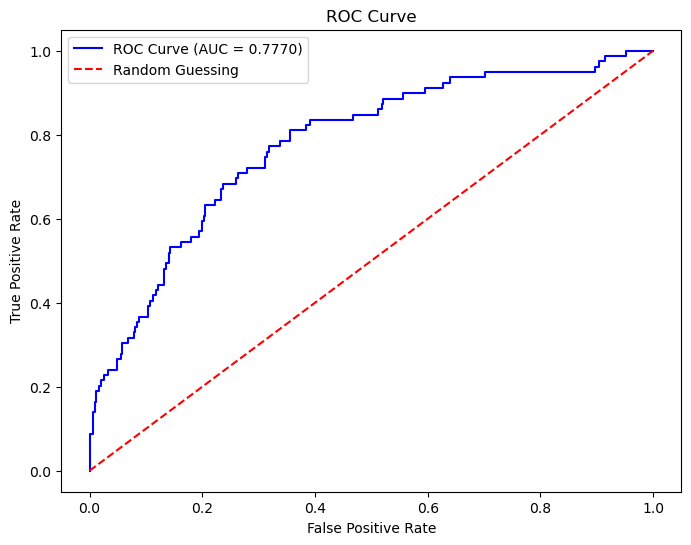

In [102]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()